# MoodSync


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import cv2
import sklearn

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Basic Exploration of FER-2013 Image Dataset
import os

dataset_dir = 'D:/MoodSync/dataset/fer2013'

for split in ['train', 'test']:
    print(f"\n{split.capitalize()} Set - Classes and Image Counts:")
    split_path = os.path.join(dataset_dir, split)
    for emotion in os.listdir(split_path):
        emotion_path = os.path.join(split_path, emotion)
        num_images = len(os.listdir(emotion_path))
        print(f"  - {emotion}: {num_images} images")


Train Set - Classes and Image Counts:
  - angry: 3995 images
  - happy: 7215 images
  - neutral: 4965 images
  - sad: 4830 images
  - surprise: 3171 images

Test Set - Classes and Image Counts:
  - angry: 958 images
  - happy: 1774 images
  - neutral: 1233 images
  - sad: 1247 images
  - surprise: 831 images


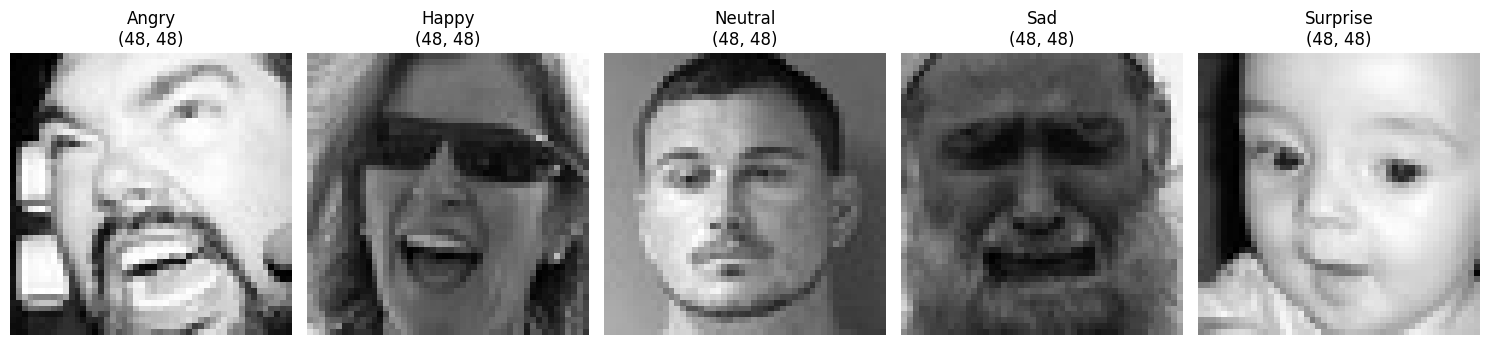

In [3]:
# Visualize one sample image from each emotion in the training set
import random

train_dir = os.path.join(dataset_dir, 'train')
emotions = os.listdir(train_dir)

plt.figure(figsize=(15, 5))
for i, emotion in enumerate(emotions):
    emotion_path = os.path.join(train_dir, emotion)
    images = os.listdir(emotion_path)
    sample_image = random.choice(images)
    img_path = os.path.join(emotion_path, sample_image)
    
    # Read and display image using OpenCV & Matplotlib
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    plt.subplot(1, len(emotions), i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{emotion.capitalize()}\n{img.shape}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Check image dimensions and pixel value range
import numpy as np

sample_size = 100
dimensions = set()
pixel_mins = []
pixel_maxs = []

train_dir = 'D:/MoodSync/dataset/fer2013/train'
for emotion in os.listdir(train_dir):
    emotion_path = os.path.join(train_dir, emotion)
    images = os.listdir(emotion_path)
    
    # Sample some images
    sampled_images = np.random.choice(images, min(sample_size, len(images)), replace=False)
    for img_name in sampled_images:
        img_path = os.path.join(emotion_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None:
            dimensions.add(img.shape)
            pixel_mins.append(img.min())
            pixel_maxs.append(img.max())

print(f"Unique image dimensions across samples: {dimensions}")
print(f"Global Pixel value range: min={min(pixel_mins)}, max={max(pixel_maxs)}")


Unique image dimensions across samples: {(48, 48)}
Global Pixel value range: min=0, max=255


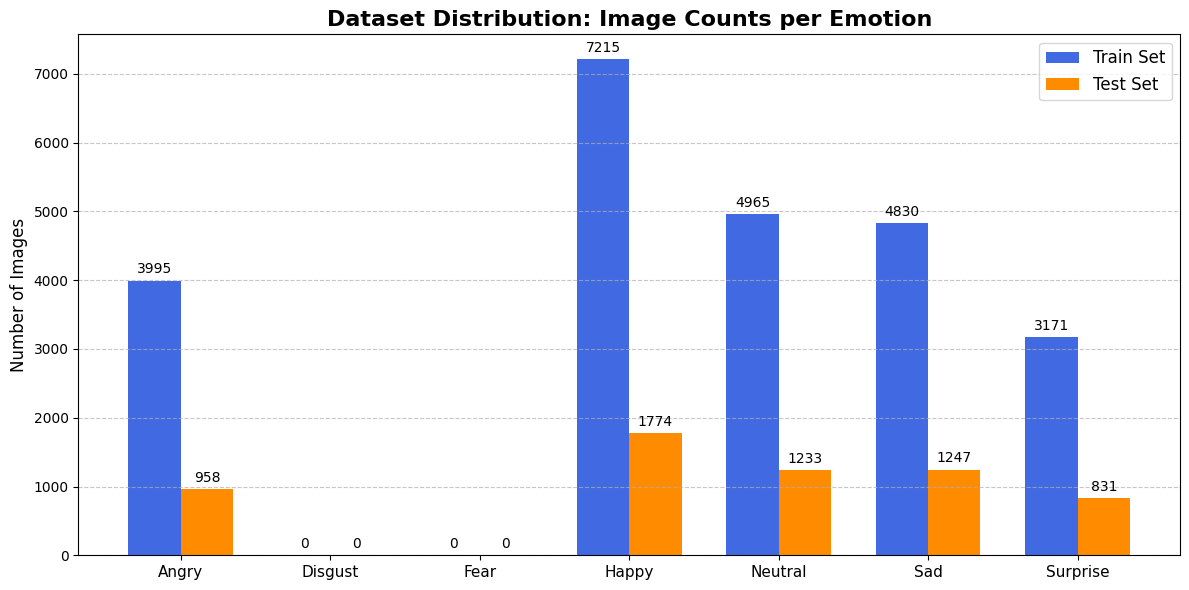

Total Training Images: 24176
Total Test Images: 6043


In [5]:
# Visualize the distribution of images across emotions for Train and Test sets
import os
import matplotlib.pyplot as plt
import numpy as np
dataset_dir = 'D:/MoodSync/dataset/fer2013'
splits = ['train', 'test']
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
train_counts = []
test_counts = []
# Gather counts for each class
for split in splits:
    split_path = os.path.join(dataset_dir, split)
    for emotion in classes:
        emotion_path = os.path.join(split_path, emotion)
        if os.path.exists(emotion_path):
            count = len(os.listdir(emotion_path))
        else:
            count = 0
            
        if split == 'train':
            train_counts.append(count)
        else:
            test_counts.append(count)

# Set up the bar chart
x = np.arange(len(classes))
width = 0.35  

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, train_counts, width, label='Train Set', color='royalblue')
rects2 = ax.bar(x + width/2, test_counts, width, label='Test Set', color='darkorange')

ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Dataset Distribution: Image Counts per Emotion', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in classes], fontsize=11)
ax.legend(fontsize=12)

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Total Training Images: {sum(train_counts)}")
print(f"Total Test Images: {sum(test_counts)}")


In [6]:
#  Data Balancing and Image Preprocessing
max_train_per_class = 2000
img_size = 48

def load_and_preprocess_data(split, balance=False):
    X, y = [], []
    split_path = os.path.join(dataset_dir, split)
    classes = sorted(os.listdir(split_path))
    
    for emotion in classes:
        emotion_path = os.path.join(split_path, emotion)
        if not os.path.isdir(emotion_path): continue
            
        images = os.listdir(emotion_path)
        
        # Balance training data to max 2000 images per class
        if balance:
            np.random.shuffle(images)
            selected_images = images[:max_train_per_class]
        else:
            selected_images = images 
            
        for img_name in selected_images:
            img_path = os.path.join(emotion_path, img_name)
            
            # Grayscale & Resize
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (img_size, img_size))
                X.append(img)
                y.append(emotion)
                
    # Reshape (adding channel dimension) and normalize (0 - 1)
    X = np.array(X).reshape(-1, img_size, img_size, 1)
    X = X.astype('float32') / 255.0
    return X, np.array(y), classes

X_train, y_train_labels, train_classes = load_and_preprocess_data('train', balance=True)

X_test, y_test_labels, _ = load_and_preprocess_data('test', balance=False)
print("Data loading & image preprocessing complete!")


Data loading & image preprocessing complete!


In [7]:
# Encode String Labels to Categorical (One-Hot Formatting)
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()

# Convert text labels ('happy', 'sad') to numbers (0, 1, 2...)
y_train_int = label_encoder.fit_transform(y_train_labels)
y_test_int = label_encoder.transform(y_test_labels)

# Convert numbered labels to One-Hot columns for the Neural Network
y_train = to_categorical(y_train_int, num_classes=len(train_classes))
y_test = to_categorical(y_test_int, num_classes=len(train_classes))

print("Labels successfully encoded into categorical format")


Labels successfully encoded into categorical format


X_train shape: (10000, 48, 48, 1) (Images)
y_train shape: (10000, 5) (Labels)
X_test shape:  (6043, 48, 48, 1) (Images)
y_test shape:  (6043, 5) (Labels)


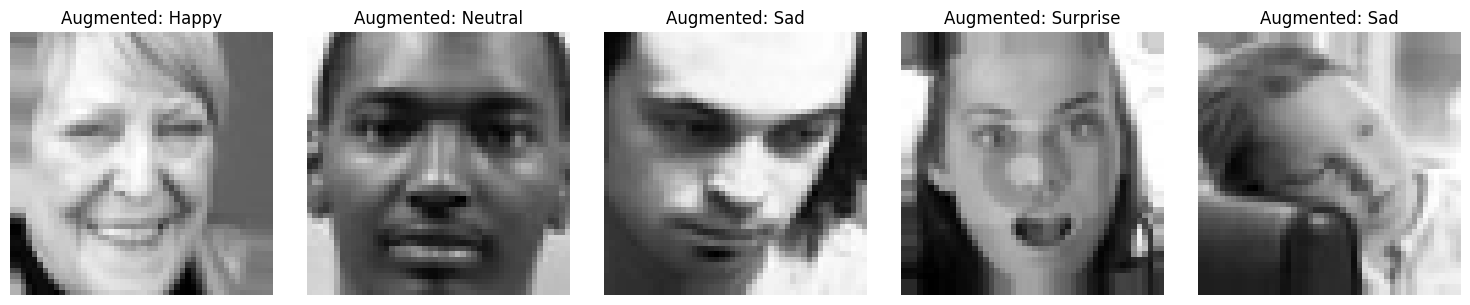

In [8]:
# Data Augmentation & Final Output Verification

# Set up augmentation (Rotation, Zoom, Horizontal Flip) for training only
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)
datagen.fit(X_train)


print(f"X_train shape: {X_train.shape} (Images)")
print(f"y_train shape: {y_train.shape} (Labels)")
print(f"X_test shape:  {X_test.shape} (Images)")
print(f"y_test shape:  {y_test.shape} (Labels)")

# Show sample augmented images
aug_iter = datagen.flow(X_train, y_train, batch_size=5)
aug_images, aug_labels = next(aug_iter)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = aug_images[i].squeeze() 
    label_idx = np.argmax(aug_labels[i])
    label_str = label_encoder.inverse_transform([label_idx])[0]
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Augmented: {label_str.capitalize()}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [9]:
print("Training Data Distribution (Images per Emotion):")

unique_classes, counts = np.unique(y_train_labels, return_counts=True)

for cls, count in zip(unique_classes, counts):
    print(f"  {cls.capitalize()}: {count} images")

print(f"\nTotal Balanced Training Images: {len(y_train_labels)}")


Training Data Distribution (Images per Emotion):
  Angry: 2000 images
  Happy: 2000 images
  Neutral: 2000 images
  Sad: 2000 images
  Surprise: 2000 images

Total Balanced Training Images: 10000


In [5]:
# saving the sets to faster use
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Loading preprocessed data instantly from disk")
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_test  = np.load('X_test.npy')
y_test  = np.load('y_test.npy')
train_classes = np.load('classes.npy')

# Re-initialize the Image Augmentation logic
datagen = ImageDataGenerator(rotation_range=15, zoom_range=0.15, horizontal_flip=True)
datagen.fit(X_train)

print(f"Data loaded")




Loading preprocessed data instantly from disk
Data loaded


In [ ]:
"""
# 1.1 Custom VGG-Style Architecture 
"""
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

fer_net = Sequential([
    # VGG Block 1 
    Conv2D(64, (3, 3), padding='same', activation='elu', input_shape=(48, 48, 1)),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='elu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # VGG Block 2 
    Conv2D(128, (3, 3), padding='same', activation='elu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='elu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    # VGG Block 3 
    Conv2D(256, (3, 3), padding='same', activation='elu'),
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='elu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.5),

    # Final Classifier
    Flatten(),
    Dense(128, activation='elu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(5, activation='softmax') # 5 emotions
])

fer_net.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(f" Total Parameters: {fer_net.count_params()}")



 Total Parameters: 2328773


In [7]:
"""
# 1.2 TRAIN THE DEEP FER-NET
# Uses Data Augmentation 
"""
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Secret Weapon: Slightly rotate/shift images so the AI learns perfectly
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# Smart Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

print("🚀 Starting Deep VGG-Style Training...")
history_fernet = fer_net.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    validation_data=(X_test, y_test),
    epochs=50,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Training Complete!")


🚀 Starting Deep VGG-Style Training...
Epoch 1/50
79/79 [==============================] - 176s 2s/step - loss: 2.0774 - accuracy: 0.2729 - val_loss: 2.1597 - val_accuracy: 0.2419 - lr: 0.0010
Epoch 2/50
79/79 [==============================] - 162s 2s/step - loss: 1.7398 - accuracy: 0.3172 - val_loss: 1.8810 - val_accuracy: 0.2073 - lr: 0.0010
Epoch 3/50
79/79 [==============================] - 173s 2s/step - loss: 1.6200 - accuracy: 0.3498 - val_loss: 1.7150 - val_accuracy: 0.2049 - lr: 0.0010
Epoch 4/50
79/79 [==============================] - 188s 2s/step - loss: 1.4545 - accuracy: 0.4037 - val_loss: 1.4775 - val_accuracy: 0.3278 - lr: 0.0010
Epoch 5/50
79/79 [==============================] - 169s 2s/step - loss: 1.3356 - accuracy: 0.4534 - val_loss: 1.3473 - val_accuracy: 0.4715 - lr: 0.0010
Epoch 6/50
79/79 [==============================] - 185s 2s/step - loss: 1.2516 - accuracy: 0.4814 - val_loss: 1.1776 - val_accuracy: 0.5120 - lr: 0.0010
Epoch 7/50
79/79 [====================

In [8]:

#1.3 
loss, accuracy = fer_net.evaluate(X_test, y_test, verbose=0)

print(f"FINAL FER-NET VGG ACCURACY: {accuracy * 100:.2f}%")
fer_net.save('moodsync_fernet_vgg.h5')



FINAL FER-NET VGG ACCURACY: 71.45%


In [ ]:
""" 2.1 Custom Lightweight CNN

"""

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Build the Model Architecture
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Final Classifier
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(len(train_classes), activation='softmax') # Output 7 emotions
])

# Compile the math
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(f"Total Model Parameters: {model.count_params()}")



Total Model Parameters: 356997


In [ ]:
# 2.3 Training the cnn Model
from tensorflow.keras.callbacks import EarlyStopping

print("Starting Training!")

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_test, y_test),
    epochs=60,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)
model.save('moodsync_custom_cnn.h5')
print("Training Complete and Model Saved as 'moodsync_custom_cnn.h5'!")


Starting Training!
Epoch 1/60
157/157 [==============================] - 31s 184ms/step - loss: 1.0798 - accuracy: 0.5683 - val_loss: 0.9999 - val_accuracy: 0.6045
Epoch 2/60
157/157 [==============================] - 29s 184ms/step - loss: 1.0614 - accuracy: 0.5761 - val_loss: 0.9970 - val_accuracy: 0.6113
Epoch 3/60
157/157 [==============================] - 30s 190ms/step - loss: 1.0603 - accuracy: 0.5710 - val_loss: 0.9905 - val_accuracy: 0.6098
Epoch 4/60
157/157 [==============================] - 30s 191ms/step - loss: 1.0488 - accuracy: 0.5814 - val_loss: 1.0660 - val_accuracy: 0.5785
Epoch 5/60
157/157 [==============================] - 30s 192ms/step - loss: 1.0321 - accuracy: 0.5879 - val_loss: 0.9444 - val_accuracy: 0.6262
Epoch 6/60
157/157 [==============================] - 30s 189ms/step - loss: 1.0164 - accuracy: 0.5964 - val_loss: 0.9816 - val_accuracy: 0.6235
Epoch 7/60
157/157 [==============================] - 30s 190ms/step - loss: 1.0200 - accuracy: 0.5921 - val_lo

In [ ]:
#2.3
from tensorflow.keras.models import load_model
model = load_model('moodsync_custom_cnn.h5')
loss,accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Final CNN Accuracy: {accuracy * 100:.2f}%")


Final CNN Accuracy: 64.80%


In [ ]:
"""
# 3.1 DenseNet121 
"""
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Loading Official DenseNet121 Architecture")

base_model = DenseNet121(
    input_shape=(48, 48, 3), 
    include_top=False, 
    weights=None      
) 

model_densenet = Sequential([
    base_model,
    GlobalAveragePooling2D(), 
    Dense(256, activation='elu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(len(train_classes), activation='softmax')
])


model_densenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(f"Total Parameters: {model_densenet.count_params()} ")



Loading Official DenseNet121 Architecture
Total Parameters: 7302213 


In [ ]:

#3.2
print("\nStarting DenseNet121 Training!")

history_dense = model_densenet.fit(
    datagen.flow(X_train_rgb, y_train, batch_size=64),
    validation_data=(X_test_rgb, y_test),
    epochs=40,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
    ]
)

model_densenet.save('moodsync_densenet121.h5')
print("Training Complete and Model Saved as 'moodsync_densenet121.h5'!")


Starting DenseNet121 Training!
Epoch 1/40
157/157 [==============================] - 323s 2s/step - loss: 2.0366 - accuracy: 0.2431 - val_loss: 1.6245 - val_accuracy: 0.2065 - lr: 0.0010
Epoch 2/40
157/157 [==============================] - 241s 2s/step - loss: 1.6952 - accuracy: 0.3298 - val_loss: 2.0068 - val_accuracy: 0.1979 - lr: 0.0010
Epoch 3/40
157/157 [==============================] - 242s 2s/step - loss: 1.6084 - accuracy: 0.3620 - val_loss: 29.0760 - val_accuracy: 0.2318 - lr: 0.0010
Epoch 4/40
157/157 [==============================] - 243s 2s/step - loss: 1.5498 - accuracy: 0.3843 - val_loss: 1.5685 - val_accuracy: 0.2510 - lr: 0.0010
Epoch 5/40
157/157 [==============================] - 243s 2s/step - loss: 1.5816 - accuracy: 0.3604 - val_loss: 38.4883 - val_accuracy: 0.2386 - lr: 0.0010
Epoch 6/40
157/157 [==============================] - 243s 2s/step - loss: 1.4852 - accuracy: 0.3992 - val_loss: 2.5531 - val_accuracy: 0.2257 - lr: 0.0010
Epoch 7/40
157/157 [==========

In [ ]:
#3.3
from tensorflow.keras.models import load_model
model = load_model('moodsync_densenet121.h5')

loss, accuracy = model.evaluate(X_test_rgb, y_test, verbose=0)
print(f"Final DenseNet Accuracy: {accuracy * 100:.2f}%")


Final DenseNet Accuracy: 56.02%


In [10]:
"""
# COMPUTE METRICS FOR ALL MODELS

"""
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

model_metrics = {}
models_to_test = {
    'FERNET': 'moodsync_fernet_vgg.h5',
    'Custom CNN': 'moodsync_custom_cnn.h5',
    'DenseNet121': 'moodsync_densenet121.h5'
}

X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')
y_true_classes = np.argmax(y_test, axis=1)

for model_name, file_path in models_to_test.items():
    print(f"[{model_name}]")
    model = load_model(file_path)
    if model.input_shape[-1] == 3: X_test_format = np.repeat(X_test, 3, axis=-1)
    else: X_test_format = X_test
        
    y_pred_probs = model.predict(X_test_format, verbose=0)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    
    # Calculate Sklearn Metrics
    acc = accuracy_score(y_true_classes, y_pred_classes)
    prec = precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
    rec = recall_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
    f1 = f1_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    
    fpr = dict(); tpr = dict(); roc_auc = dict()
    for i in range(5):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    macro_auc = sum(roc_auc.values()) / 5
    
    print(f"  Accuracy:  {acc * 100:.2f}%")
    print(f"  Precision: {prec * 100:.2f}%")
    print(f"  Recall:    {rec * 100:.2f}%")
    print(f"  F1-Score:  {f1 * 100:.2f}%")
    print(f"  AUC Score: {macro_auc:.4f}\n")
    
    model_metrics[model_name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 
        'AUC': macro_auc, 'Confusion_Matrix': cm, 'FPR': fpr, 'TPR': tpr, 'ROC_AUC': roc_auc
    }



[FERNET]
  Accuracy:  71.45%
  Precision: 72.28%
  Recall:    71.45%
  F1-Score:  71.60%
  AUC Score: 0.9220

[Custom CNN]
  Accuracy:  64.80%
  Precision: 65.22%
  Recall:    64.80%
  F1-Score:  64.80%
  AUC Score: 0.8865

[DenseNet121]
  Accuracy:  56.02%
  Precision: 58.93%
  Recall:    56.02%
  F1-Score:  56.15%
  AUC Score: 0.8476



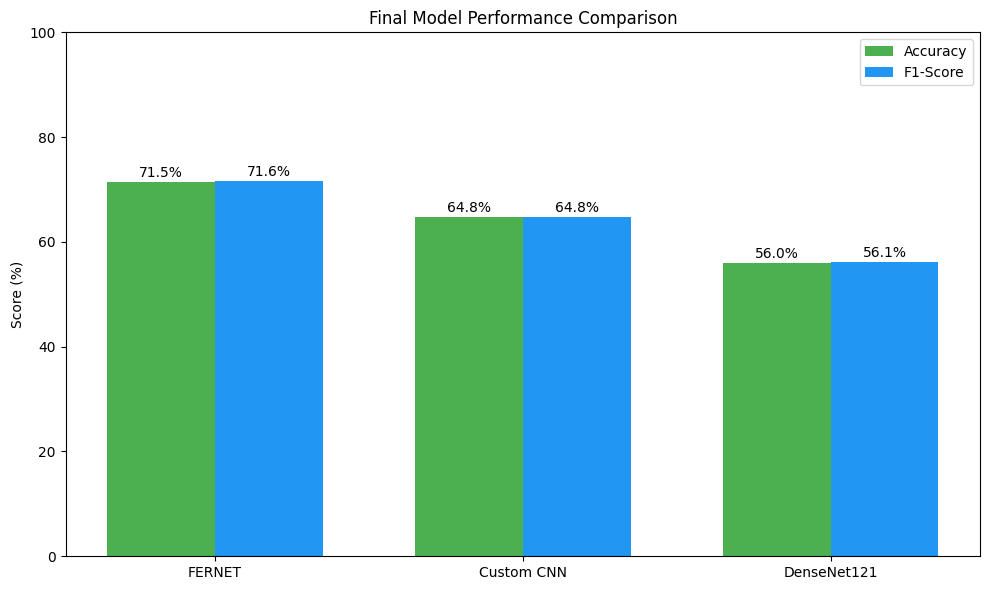

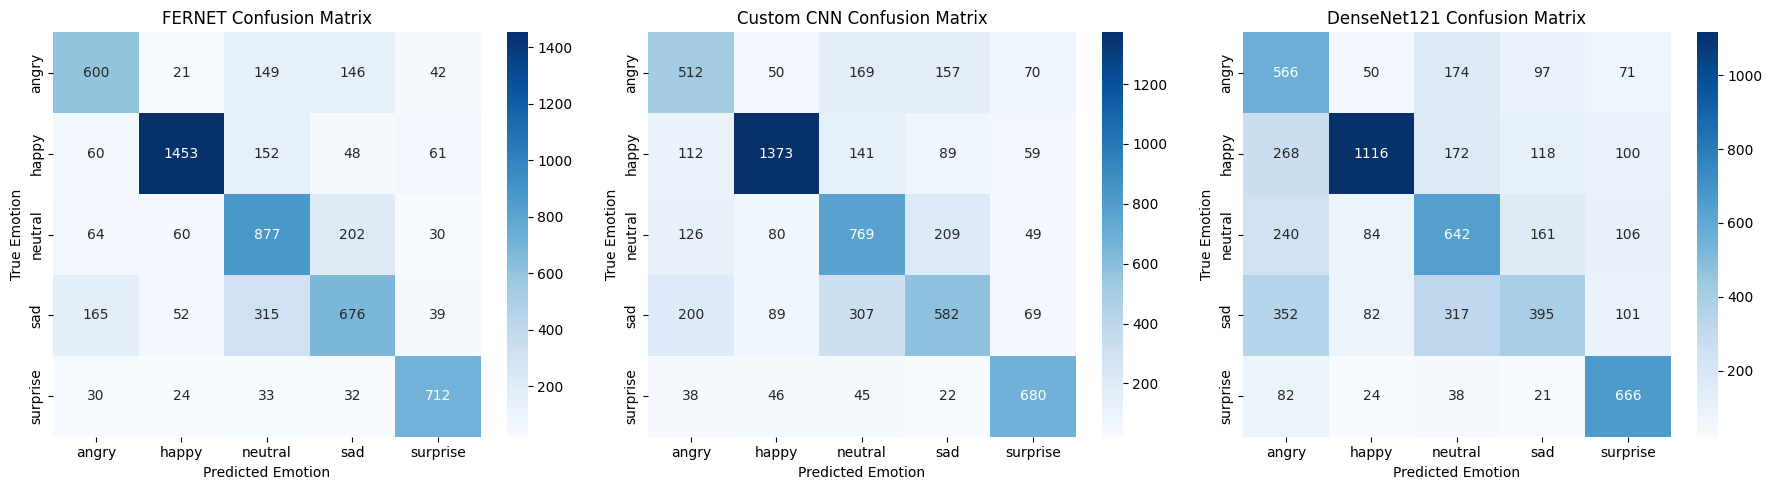

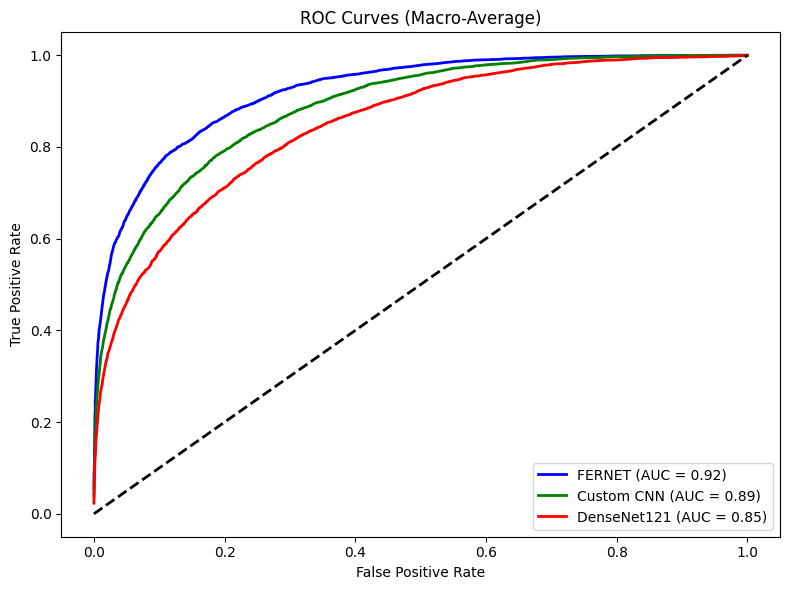

In [11]:
"""
#  PRESENTATION GRAPHS
"""
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

classes = ['angry', 'happy', 'neutral', 'sad', 'surprise'] 
models = list(model_metrics.keys())

#  PERFORMANCE BAR CHART 
plt.figure(figsize=(10, 6))
acc_scores = [model_metrics[m]['Accuracy'] * 100 for m in models]
f1_scores = [model_metrics[m]['F1-Score'] * 100 for m in models]
x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, acc_scores, width, label='Accuracy', color='#4CAF50')
plt.bar(x + width/2, f1_scores, width, label='F1-Score', color='#2196F3')

plt.ylabel('Score (%)'); plt.title('Final Model Performance Comparison')
plt.xticks(x, models); plt.legend(); plt.ylim([0, 100])
for i in range(len(models)):
    plt.text(x[i] - width/2, acc_scores[i] + 1, f"{acc_scores[i]:.1f}%", ha='center')
    plt.text(x[i] + width/2, f1_scores[i] + 1, f"{f1_scores[i]:.1f}%", ha='center')
plt.tight_layout()
plt.show()

#  CONFUSION MATRICES HEATMAPS 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, model_name in enumerate(models):
    sns.heatmap(model_metrics[model_name]['Confusion_Matrix'], annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, ax=axes[i])
    axes[i].set_title(f'{model_name} Confusion Matrix')
    axes[i].set_ylabel('True Emotion'); axes[i].set_xlabel('Predicted Emotion')
plt.tight_layout()
plt.show()

#  ROC CURVES (Macro Average) 
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
for i, model_name in enumerate(models):
    # Plotting Macro-Average ROC for exactly how well the model handles all 5 classes under pressure
    all_fpr = np.unique(np.concatenate([model_metrics[model_name]['FPR'][c] for c in range(5)]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in range(5): mean_tpr += np.interp(all_fpr, model_metrics[model_name]['FPR'][c], model_metrics[model_name]['TPR'][c])
    mean_tpr /= 5
    plt.plot(all_fpr, mean_tpr, color=colors[i], lw=2, label=f'{model_name} (AUC = {model_metrics[model_name]["AUC"]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curves (Macro-Average)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [1]:
"""
REALTIME DETECTION WITH MUSIC RECCOMENDATIONS
"""
import cv2
import numpy as np
from collections import deque
from tensorflow.keras.models import load_model
import os


#model = load_model('moodsync_custom_cnn.h5')      
model = load_model('moodsync_fernet_vgg.h5')      
#model = load_model('moodsync_densenet121.h5')     

USE_RGB = (model.input_shape[-1] == 3)

classes = ['angry', 'happy', 'neutral', 'sad', 'surprise']

music_map = {
    'angry':    '🎵 Relaxing Music - Lo-fi / Acoustic',
    'happy':    '🎵 Upbeat Music - Pop / Dance / EDM',
    'neutral':  '🎵 Neutral Playlist - Ambient / Chill',
    'sad':      '🎵 Calm Music - Piano / Soft Acoustic',
    'surprise': '🎵 Energetic Music - Rock / Hype Beats'
}

color_map = {
    'angry':    (0, 0, 255),
    'happy':    (0, 255, 0),
    'neutral':  (255, 200, 0),
    'sad':      (255, 0, 0),
    'surprise': (0, 255, 255)
}

# Load OpenCV's Deep Learning Face Detector
dnn_dir = os.path.join(os.path.dirname(os.path.abspath('MoodSync.ipynb')), 'face_dnn')
os.makedirs(dnn_dir, exist_ok=True)
proto_path = os.path.join(dnn_dir, 'deploy.prototxt')
model_path = os.path.join(dnn_dir, 'res10_300x300_ssd_iter_140000.caffemodel')

if not os.path.exists(proto_path) or not os.path.exists(model_path):
    print("Downloading DNN Face Detector files (one-time only)...")
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt",
        proto_path)
    urllib.request.urlretrieve(
        "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel",
        model_path)
    print("✅ Downloaded successfully!")

face_net = cv2.dnn.readNetFromCaffe(proto_path, model_path)

# Smoothing Buffer: Stores the last 15 predictions to stabilize the output
prediction_buffer = deque(maxlen=15)

cap = cv2.VideoCapture(0)

# Create a resizable window
WINDOW_NAME = 'MoodSync - Real-Time Emotion Detection'
cv2.namedWindow(WINDOW_NAME, cv2.WINDOW_NORMAL)
cv2.resizeWindow(WINDOW_NAME, 960, 720)

print("Webcam opened! Press 'q' on the video window to close.")

while True:
    ret, frame = cap.read()
    if not ret: break

    h, w = frame.shape[:2]

    # DNN Face Detection
    blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104, 177, 123))
    face_net.setInput(blob)
    detections = face_net.forward()

    for i in range(detections.shape[2]):
        confidence_face = detections[0, 0, i, 2]
        if confidence_face < 0.5: continue

        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        x1, y1, x2, y2 = box.astype("int")
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        if x2 - x1 < 10 or y2 - y1 < 10: continue

        # Crop and preprocess face
        roi = cv2.cvtColor(frame[y1:y2, x1:x2], cv2.COLOR_BGR2GRAY)
        roi = cv2.resize(roi, (48, 48)).astype('float32') / 255.0

        if USE_RGB:
            final = np.expand_dims(np.repeat(roi[..., np.newaxis], 3, axis=-1), axis=0)
        else:
            final = roi.reshape(1, 48, 48, 1)

        # Predict and add to smoothing buffer
        pred = model.predict(final, verbose=0)[0]
        prediction_buffer.append(pred)

        # Average the last N predictions for stability
        avg_pred = np.mean(prediction_buffer, axis=0)
        emotion = classes[np.argmax(avg_pred)]
        conf = np.max(avg_pred) * 100
        color = color_map[emotion]

        # Draw bounding box
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        # Draw emotion label + confidence
        label = f"{emotion.capitalize()} ({conf:.1f}%)"
        cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

        # Draw music recommendation banner at bottom
        music = music_map[emotion]
        cv2.rectangle(frame, (0, h - 50), (w, h), (30, 30, 30), -1)
        cv2.putText(frame, music, (10, h - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    cv2.imshow(WINDOW_NAME, frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print(" Webcam closed successfully!")


✅ Downloaded successfully!
Webcam opened! Press 'q' on the video window to close.
 Webcam closed successfully!
